In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../reports', exist_ok=True)

# All metrics from previous notebooks
data = {
    'origin'         : ['organic_search','direct_traffic','referral','paid_search','email','social','display'],
    'assumed_spend'  : [5000, 2000, 3000, 50000, 10000, 40000, 20000],
    'converted_leads': [271, 56, 24, 195, 15, 75, 6],
    'total_revenue'  : [293711, 33242, 22026, 251088, 9229, 67671, 1207],
    'CAC'            : [18.45, 35.71, 125.00, 256.41, 666.67, 533.33, 3333.33],
    'ROAS'           : [58.74, 16.62, 7.34, 5.02, 0.92, 1.69, 0.06],
    'LTV_CAC'        : [11.27, 4.16, 2.18, 0.65, 0.58, 0.27, 0.05]
}

df = pd.DataFrame(data)
print(df)

           origin  assumed_spend  converted_leads  total_revenue      CAC  \
0  organic_search           5000              271         293711    18.45   
1  direct_traffic           2000               56          33242    35.71   
2        referral           3000               24          22026   125.00   
3     paid_search          50000              195         251088   256.41   
4           email          10000               15           9229   666.67   
5          social          40000               75          67671   533.33   
6         display          20000                6           1207  3333.33   

    ROAS  LTV_CAC  
0  58.74    11.27  
1  16.62     4.16  
2   7.34     2.18  
3   5.02     0.65  
4   0.92     0.58  
5   1.69     0.27  
6   0.06     0.05  


In [2]:
total_budget = df['assumed_spend'].sum()  # R$ 130,000

# Score = normalized ROAS * LTV_CAC
df['score'] = (df['ROAS'] * df['LTV_CAC'])
df['score_normalized'] = df['score'] / df['score'].sum()

# Recommended budget based on score
df['recommended_spend'] = (df['score_normalized'] * total_budget).round(0)

# Budget change
df['budget_change'] = df['recommended_spend'] - df['assumed_spend']
df['change_%'] = ((df['budget_change'] / df['assumed_spend']) * 100).round(1)

print(df[['origin','assumed_spend','recommended_spend','budget_change','change_%']]
      .sort_values('recommended_spend', ascending=False))

           origin  assumed_spend  recommended_spend  budget_change  change_%
0  organic_search           5000           114533.0       109533.0    2190.7
1  direct_traffic           2000            11962.0         9962.0     498.1
2        referral           3000             2768.0         -232.0      -7.7
3     paid_search          50000              565.0       -49435.0     -98.9
4           email          10000               92.0        -9908.0     -99.1
5          social          40000               79.0       -39921.0     -99.8
6         display          20000                1.0       -19999.0    -100.0


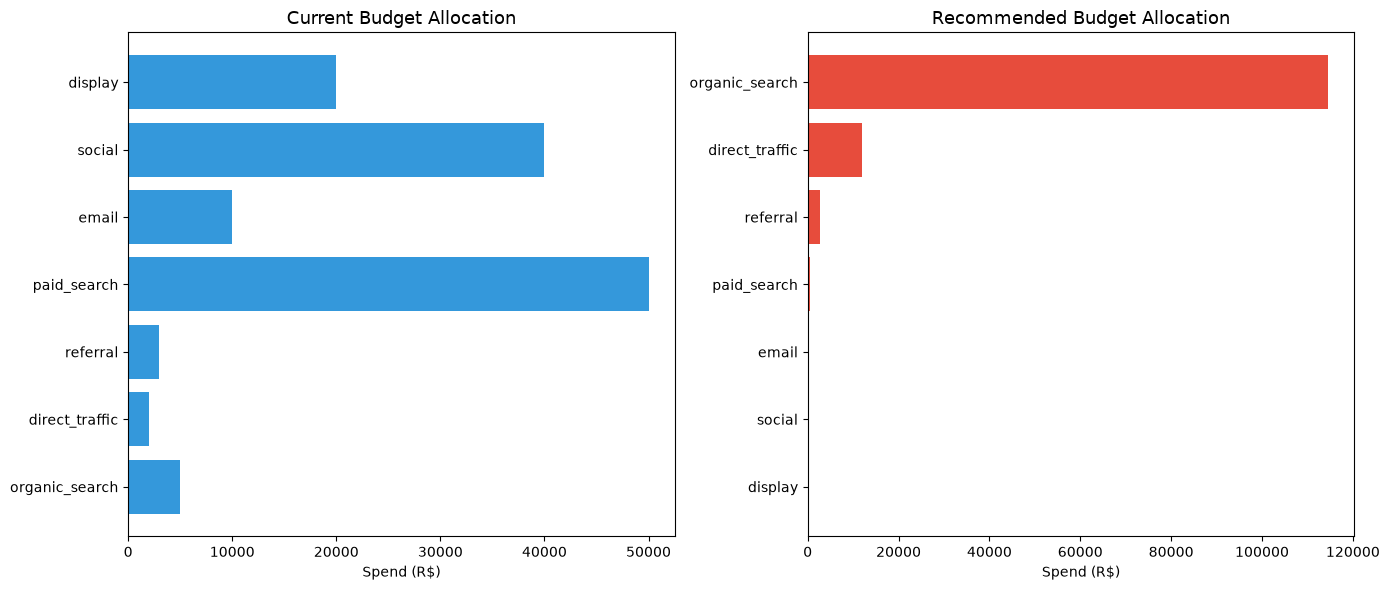

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_current = ['#3498db'] * len(df)
colors_recommend = ['#2ecc71' if x > 0 else '#e74c3c' 
                    for x in df['budget_change']]

axes[0].barh(df['origin'], df['assumed_spend'], color='#3498db')
axes[0].set_title('Current Budget Allocation', fontsize=13)
axes[0].set_xlabel('Spend (R$)')

axes[1].barh(df.sort_values('recommended_spend', ascending=True)['origin'],
             df.sort_values('recommended_spend', ascending=True)['recommended_spend'],
             color=colors_recommend)
axes[1].set_title('Recommended Budget Allocation', fontsize=13)
axes[1].set_xlabel('Spend (R$)')

plt.tight_layout()
plt.savefig('../reports/04_budget_comparison.png', dpi=150)
plt.show()

In [4]:
summary = df[['origin','assumed_spend','recommended_spend',
              'ROAS','LTV_CAC','budget_change']].copy()

summary['action'] = summary['budget_change'].apply(
    lambda x: '🚀 Scale Up' if x > 5000 
    else '✅ Maintain' if x >= 0 
    else '⚠️ Reduce' if x > -10000 
    else '❌ Cut'
)

summary = summary.sort_values('recommended_spend', ascending=False)
print("\n===== MARKETLENS — FINAL BUDGET RECOMMENDATION =====\n")
print(summary[['origin','assumed_spend','recommended_spend','ROAS','LTV_CAC','action']].to_string(index=False))
print(f"\nTotal Budget : R$ {total_budget:,.0f}")
print(f"No new spend — only reallocation.")


===== MARKETLENS — FINAL BUDGET RECOMMENDATION =====

        origin  assumed_spend  recommended_spend  ROAS  LTV_CAC     action
organic_search           5000           114533.0 58.74    11.27 🚀 Scale Up
direct_traffic           2000            11962.0 16.62     4.16 🚀 Scale Up
      referral           3000             2768.0  7.34     2.18  ⚠️ Reduce
   paid_search          50000              565.0  5.02     0.65      ❌ Cut
         email          10000               92.0  0.92     0.58  ⚠️ Reduce
        social          40000               79.0  1.69     0.27      ❌ Cut
       display          20000                1.0  0.06     0.05      ❌ Cut

Total Budget : R$ 130,000
No new spend — only reallocation.


In [5]:
summary.to_csv('../reports/marketlens_final_recommendations.csv', index=False)
print("Report saved to reports/marketlens_final_recommendations.csv ✓")

Report saved to reports/marketlens_final_recommendations.csv ✓
